# 01 · Carbon Transition DuckDB — End-to-End Workflow

This notebook walks through the full local workflow of the lab:

1. Generate synthetic OWID-like data (no network needed).
2. Build a DuckDB database and materialize Parquet marts.
3. Inspect the country-year mart with SQL.
4. Compute transparent transition-risk scores.
5. Visualize and report the results.

Swap the synthetic generator for `carbon-duckdb download-owid` to run the exact same steps on the real Our World in Data files.

> The transition-risk score is an **exploratory screening signal**, not a moral ranking or a causal claim about climate policy.

## Setup

Resolve paths and import plotting helpers.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


def find_repo_root(start: Path | None = None) -> Path:
    """Walk upwards until the directory containing pyproject.toml is found."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here


REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / "data" / "raw"
DB_PATH = REPO_ROOT / "data" / "processed" / "carbon_transition.duckdb"
MARTS_DIR = REPO_ROOT / "data" / "processed" / "marts"
REPORTS_DIR = REPO_ROOT / "reports" / "sample_run"
print(f"Repository root: {REPO_ROOT}")


Repository root: C:\Users\diogo\work_code\portfolio\carbon-transition-duckdb-lab


## 1. Generate synthetic raw data

The generator produces small, deterministic CO2 and energy CSV files that mirror the shape of the OWID datasets.

In [2]:
from carbon_transition_duckdb.sample_data import generate_synthetic_owid_data

co2_path, energy_path = generate_synthetic_owid_data(
    RAW_DIR, start_year=2010, end_year=2024
)
co2 = pd.read_csv(co2_path)
energy = pd.read_csv(energy_path)
print(f"CO2 rows: {len(co2)} | Energy rows: {len(energy)}")
co2.head()

CO2 rows: 75 | Energy rows: 75


,country,iso_code,year,population,co2,co2_per_capita,energy_per_capita,carbon_intensity
0,Atlantis,ATL,2010,8000000,60.4976,7.5622,39.7300,0.134815
1,Atlantis,ATL,2011,8072000,59.2944,7.3457,39.5597,0.134206
2,Atlantis,ATL,2012,8144000,60.7224,7.4561,39.9062,0.157364
3,Atlantis,ATL,2013,8216000,56.9542,6.9321,39.9480,0.177859
4,Atlantis,ATL,2014,8288000,58.0023,6.9983,40.8191,0.161965


In [3]:
energy.head()

,country,iso_code,year,primary_energy_consumption,fossil_share_energy,renewables_share_energy,renewables_share_elec,electricity_generation
0,Atlantis,ATL,2010,317.8403,74.8600,18.2789,21.5241,107.4208
1,Atlantis,ATL,2011,319.3261,74.6926,18.5739,16.9657,80.9331
2,Atlantis,ATL,2012,324.9962,73.8679,21.0998,23.7405,81.5236
3,Atlantis,ATL,2013,328.2126,72.2566,22.5963,20.2733,86.0104
4,Atlantis,ATL,2014,338.3084,71.7689,24.2950,23.9447,127.3748


## 2. Build the DuckDB lakehouse

`build_duckdb_lakehouse` loads the raw CSVs into staging tables, builds the `mart_country_year_transition` table, and exports Parquet marts — all inside a single embedded `.duckdb` file.

In [4]:
from carbon_transition_duckdb.config import ProjectPaths
from carbon_transition_duckdb.pipeline import build_duckdb_lakehouse

paths = ProjectPaths(raw_dir=RAW_DIR, database=DB_PATH, export_dir=MARTS_DIR)
result = build_duckdb_lakehouse(paths)
print(f"Database : {result.database.name}")
print(f"Mart     : {result.mart_table}")
print(f"Rows     : {result.row_count}")
print("Marts    :", [p.name for p in sorted(MARTS_DIR.glob('*.parquet'))])

Database : carbon_transition.duckdb
Mart     : mart_country_year_transition
Rows     : 75
Marts    : ['mart_co2_cagr.parquet', 'mart_country_year_transition.parquet', 'mart_latest_country_transition.parquet']


## 3. Inspect the mart with SQL

DuckDB is an embedded analytical engine — we can query the database file directly with SQL and get a pandas DataFrame back.

In [5]:
import duckdb

con = duckdb.connect(str(DB_PATH))
mart = con.execute(
    """
    SELECT country, year, co2, co2_per_capita, fossil_share_energy,
           renewables_share_elec, carbon_intensity
    FROM mart_country_year_transition
    ORDER BY country, year
    """
).fetchdf()
con.close()
print(f"Mart shape: {mart.shape}")
mart.head()

Mart shape: (75, 7)


,country,year,co2,co2_per_capita,fossil_share_energy,renewables_share_elec,carbon_intensity
0,Atlantis,2010,60.4976,7.5622,74.8600,21.5241,0.190340
1,Atlantis,2011,59.2944,7.3457,74.6926,16.9657,0.185686
2,Atlantis,2012,60.7224,7.4561,73.8679,23.7405,0.186840
3,Atlantis,2013,56.9542,6.9321,72.2566,20.2733,0.173528
4,Atlantis,2014,58.0023,6.9983,71.7689,23.9447,0.171448


## 4. Score transition risk

`compute_transition_scores` reads the mart, drops aggregate entities (World, Europe, …), min-max scales each component, and combines them with transparent weights.

In [6]:
from carbon_transition_duckdb.pipeline import compute_transition_scores
from carbon_transition_duckdb.risk.scoring import latest_year

scores = compute_transition_scores(DB_PATH)
year = latest_year(scores)
ranking = (
    scores.loc[scores['year'] == year,
               ['country', 'transition_risk_score', 'risk_drivers']]
    .sort_values('transition_risk_score', ascending=False)
    .reset_index(drop=True)
)
print(f"Latest analysed year: {year}")
ranking

Latest analysed year: 2024


,country,transition_risk_score,risk_drivers
0,Deltora,68.76,low renewable electricity share; high fossil-f...
1,Borealia,58.12,high fossil-fuel share; high CO2 per capita; l...
2,Atlantis,50.99,high fossil-fuel share; high carbon intensity;...
3,Estavia,15.39,recent CO2 emissions trend; high carbon intens...
4,Cyrenia,9.85,recent CO2 emissions trend; high CO2 per capit...


## 5. Visualize the highest-risk entities

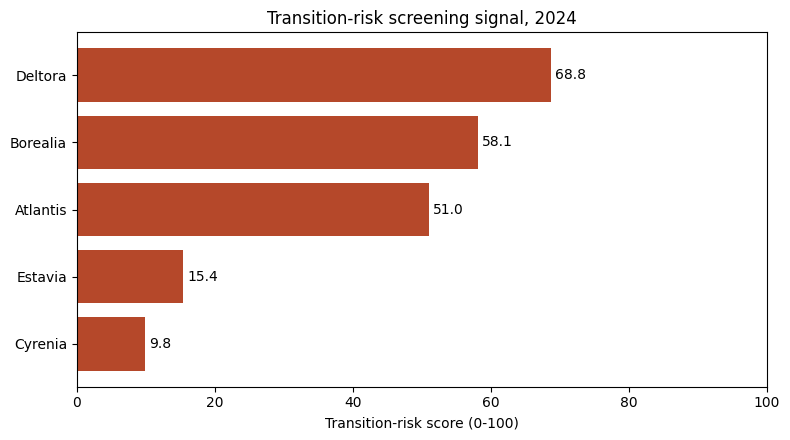

In [7]:
latest = scores.loc[scores['year'] == year].sort_values('transition_risk_score')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(latest['country'], latest['transition_risk_score'], color='#b5482a')
ax.set_xlabel('Transition-risk score (0-100)')
ax.set_title(f'Transition-risk screening signal, {year}')
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)
ax.set_xlim(0, 100)
fig.tight_layout()
plt.show()

## 6. Generate the Markdown report

The report is a compact, reviewable artifact written to `reports/sample_run/`.

In [8]:
from carbon_transition_duckdb.reporting.markdown import generate_markdown_report, write_report

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
report_path = write_report(
    scores, REPORTS_DIR / 'transition_report.md',
    title='Synthetic Carbon Transition Report',
)
print(f"Wrote {report_path.relative_to(REPO_ROOT)}\n")
print(generate_markdown_report(scores, title='Synthetic Carbon Transition Report'))

Wrote reports\sample_run\transition_report.md

# Synthetic Carbon Transition Report

Latest analysed year: **2024**.

This report ranks country-year rows by a transparent transition-risk score.
The score is exploratory and should not be interpreted as a causal judgement.

## Highest-risk rows

| Rank | Country | Score | Main drivers |
|---:|---|---:|---|
| 1 | Deltora | 68.76 | low renewable electricity share; high fossil-fuel share; high CO2 per capita |
| 2 | Borealia | 58.12 | high fossil-fuel share; high CO2 per capita; low renewable electricity share |
| 3 | Atlantis | 50.99 | high fossil-fuel share; high carbon intensity; low renewable electricity share |
| 4 | Estavia | 15.39 | recent CO2 emissions trend; high carbon intensity; low renewable electricity share |
| 5 | Cyrenia | 9.85 | recent CO2 emissions trend; high CO2 per capita; high carbon intensity |

## Method summary

The first version combines recent CO2 trend, CO2 per capita, carbon intensity, fossil-fuel share of energ

## Where to go next

- **`02_score_anatomy_and_sensitivity.ipynb`** — decompose the score and test how rankings move when the weights change.
- **`03_exploratory_analysis.ipynb`** — trends, distributions, and correlations across the country-year panel.
- **`04_duckdb_sql_analytics.ipynb`** — query the Parquet marts directly with SQL (window functions, rankings, custom exports).